# Insurance and Fertility-Related Medical Help
**Gracie Nguyen | DATA 400 | NSFG 2022–2023**

Research question: Is current insurance associated with ever receiving medical help to get pregnant, after controlling for income, education, and age?

## 1. Library Preparation & Data Overview

In [24]:
# Run once if these packages are not installed (Python 3.11+):
# %pip install svy pyarrow pandas numpy matplotlib

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import svy
import polars as pl
from IPython.display import display

pd.set_option("display.max_columns", 20)
pd.set_option("display.precision", 3)
plt.rcParams.update({"figure.figsize": (9, 5), "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})

# Notebook may be inside code/ or in the project root
ROOT = Path.cwd().parent if Path.cwd().name == "code" else Path.cwd()
TABLES = ROOT / "output" / "tables"
FIGURES = ROOT / "output" / "figures"
TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

In [25]:
# Load selected variables
columns = [
    "HLPPRG", "CURR_INS", "POVERTY", "HIEDUC", "AGER",
    "WGT2022_2023", "VEST", "VECL",
    "CURR_INS_I", "POVERTY_I", "HIEDUC_I"
]

raw = pd.read_csv(
    ROOT / "data" / "NSFG_2022_2023_FemRespPUFData.csv",
    usecols=columns
)

# Preview data
display(raw.head())

# Summary statistics
display(raw[["AGER", "POVERTY", "WGT2022_2023"]].describe())

# Missing values
display(raw.isna().sum().rename("Missing"))

,HLPPRG,AGER,HIEDUC,HIEDUC_I,CURR_INS,CURR_INS_I,POVERTY,POVERTY_I,WGT2022_2023,VEST,VECL
0,5.0,29,4,0,1,0,537,1,26421.358,8,1
1,5.0,18,5,0,1,0,150,0,11222.508,20,4
2,1.0,37,6,0,2,0,343,0,6751.302,20,4
3,1.0,40,10,0,1,0,417,0,4797.426,12,2
4,5.0,49,9,0,4,0,444,0,8864.815,12,4


,AGER,POVERTY,WGT2022_2023
count,5586.000,5586.000,5586.000
mean,32.363,314.300,13415.130
std,9.533,202.459,11142.068
min,15.000,50.000,1170.958
25%,25.000,135.000,5680.122
50%,33.000,292.000,9790.167
75%,40.000,451.000,16452.047
max,50.000,700.000,78770.134


HLPPRG          340
AGER              0
HIEDUC            0
HIEDUC_I          0
CURR_INS          0
CURR_INS_I        0
POVERTY           0
POVERTY_I         0
WGT2022_2023      0
VEST              0
VECL              0
Name: Missing, dtype: int64

**Takeaway:** The dataset includes 5,586 respondents, with information on insurance coverage, education, income, age, and fertility-related medical help.

## 2. Data Preparation

In [26]:
data = raw.copy()

# Outcome: yes = 1, no = 0
# Other responses become missing
data["help_received"] = data["HLPPRG"].map({
    1: 1,
    5: 0
})

# Label insurance categories
insurance_labels = [
    "Private/Medi-Gap",
    "Medicaid/CHIP/state",
    "Medicare/military/other govt",
    "Single-service/IHS/uninsured"
]

insurance_map = {
    1: insurance_labels[0],
    2: insurance_labels[1],
    3: insurance_labels[2],
    4: insurance_labels[3]
}

data["insurance"] = pd.Categorical(
    data["CURR_INS"].map(insurance_map),
    categories=insurance_labels
)

# Combine education into four groups
education_labels = [
    "Less than high school",
    "High school/GED",
    "Some college/associate",
    "Bachelor's or higher"
]

education_map = {
    1: "Less than high school",
    2: "Less than high school",
    3: "High school/GED",
    4: "High school/GED",
    5: "Some college/associate",
    6: "Some college/associate",
    7: "Some college/associate",
    8: "Bachelor's or higher",
    9: "Bachelor's or higher",
    10: "Bachelor's or higher",
    11: "Bachelor's or higher"
}

data["education"] = pd.Categorical(
    data["HIEDUC"].map(education_map),
    categories=education_labels
)

# Prepare numeric variables
data["age"] = data["AGER"]
data["poverty100"] = data["POVERTY"] / 100

# Rescale survey weights to average 1
data["weight"] = (
    data["WGT2022_2023"] / data["WGT2022_2023"].mean()
)

# Keep rows with complete analysis variables
required = [
    "help_received", "insurance", "education",
    "age", "poverty100", "weight", "VEST", "VECL"
]

analysis = data.dropna(subset=required).copy()

# Show sample size before and after cleaning
sample_size = pd.DataFrame({
    "Sample": ["Original", "After cleaning"],
    "Respondents": [len(raw), len(analysis)]
})

display(sample_size)

# Save cleaned analysis variables
analysis[required].to_csv(
    TABLES / "cleaned_analysis_data.csv",
    index=False
)

,Sample,Respondents
0,Original,5586
1,After cleaning,5195


**Takeaway:** After cleaning, 5,195 respondents remain for analysis. Insurance and education are organized into four categories each.

## 3. Weighted Summary Tables

Counts are unweighted. Means and percentages use survey weights. These EDA tables show point estimates; survey uncertainty is calculated in the model section.

In [27]:
# Overall sample summary
summary = pd.DataFrame({
    "Measure": ["Respondents", "Mean age", "Mean income (% poverty threshold)", "Ever received help (%)"],
    "Value": [len(analysis),
              np.average(analysis["age"], weights=analysis["weight"]),
              np.average(analysis["POVERTY"], weights=analysis["weight"]),
              np.average(analysis["help_received"], weights=analysis["weight"])*100]
})
display(summary)
summary.to_csv(TABLES / "sample_summary.csv", index=False)

# Compare insurance groups
rows = []
for label in insurance_labels:
    group = analysis[analysis["insurance"] == label]
    rows.append({
        "Insurance": label,
        "N": len(group),
        "Yes": int(group["help_received"].sum()),
        "Weighted sample %": group["weight"].sum()/analysis["weight"].sum()*100,
        "Rate %": np.average(group["help_received"], weights=group["weight"])*100,
        "Mean age": np.average(group["age"], weights=group["weight"]),
        "Mean poverty %": np.average(group["POVERTY"], weights=group["weight"])
    })
rates = pd.DataFrame(rows)
display(rates)
rates.to_csv(TABLES / "insurance_summary.csv", index=False)

# Education percentages within each insurance group
education_share = pd.crosstab(
    analysis["insurance"], analysis["education"],
    values=analysis["weight"], aggfunc="sum"
).fillna(0)
education_share = education_share.div(education_share.sum(axis=1), axis=0)*100
display(education_share)
education_share.to_csv(TABLES / "education_by_insurance.csv")

,Measure,Value
0,Respondents,5195.000
1,Mean age,33.018
2,Mean income (% poverty threshold),320.138
3,Ever received help (%),9.827


,Insurance,N,Yes,Weighted sample %,Rate %,Mean age,Mean poverty %
0,Private/Medi-Gap,3182,419,60.908,12.850,34.069,407.337
1,Medicaid/CHIP/state,1095,62,21.711,4.324,30.932,168.472
2,Medicare/military/other govt,343,23,6.193,7.840,30.553,234.865
3,Single-service/IHS/uninsured,575,27,11.188,5.148,32.705,186.933


education,Less than high school,High school/GED,Some college/associate,Bachelor's or higher
insurance,,,,
Private/Medi-Gap,3.985,14.376,27.476,54.164
Medicaid/CHIP/state,19.319,37.745,31.257,11.679
Medicare/military/other govt,11.917,28.268,36.558,23.258
Single-service/IHS/uninsured,22.762,26.395,32.391,18.453


**Takeaway:** These tables describe the sample and compare help receipt, age, income, and education across coverage groups.

## 4. Variable Distributions

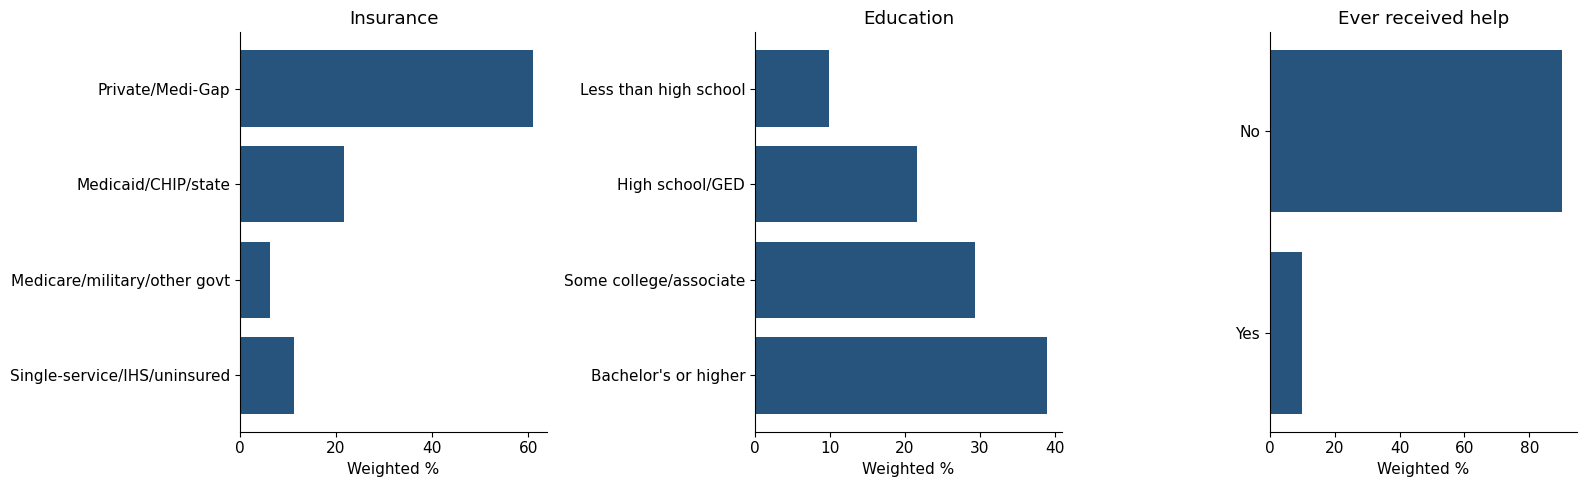

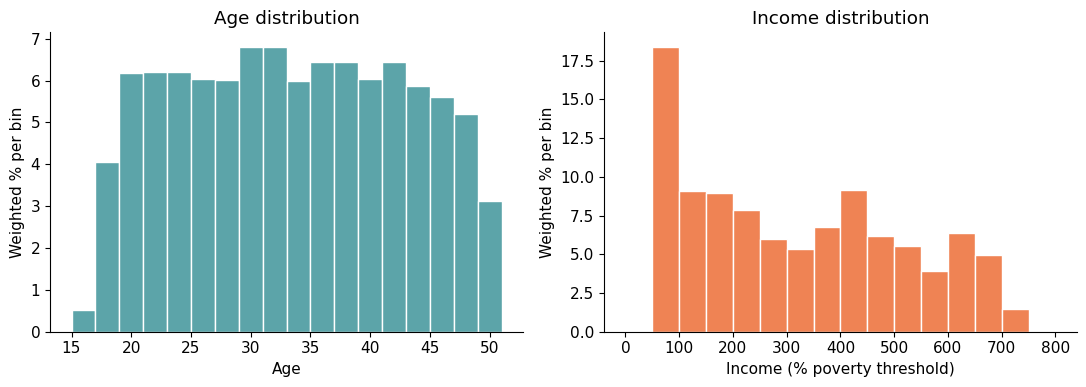

In [28]:
# Weighted distributions of insurance, education, and outcome
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, variable, title in zip(axes, ["insurance", "education", "help_received"], ["Insurance", "Education", "Ever received help"]):
    shares = analysis.groupby(variable, observed=True)["weight"].sum()
    shares = shares / shares.sum() * 100
    labels = [str(x) for x in shares.index]
    if variable == "help_received":
        labels = ["No", "Yes"]
    ax.barh(labels, shares, color="#26547C")
    ax.invert_yaxis()
    ax.set_xlabel("Weighted %")
    ax.set_title(title)
fig.tight_layout()
fig.savefig(FIGURES / "category_distributions.png", dpi=200, bbox_inches="tight")
plt.show()

# Weighted age and income distributions
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(analysis.age, bins=np.arange(15, 52, 2), weights=analysis.weight / analysis.weight.sum()*100, color="#5CA4A9", edgecolor="white")
axes[0].set(xlabel="Age", ylabel="Weighted % per bin", title="Age distribution")
axes[1].hist(analysis.POVERTY, bins=np.arange(0, 801, 50), weights=analysis.weight / analysis.weight.sum()*100, color="#EF8354", edgecolor="white")
axes[1].set(xlabel="Income (% poverty threshold)", ylabel="Weighted % per bin", title="Income distribution")
fig.tight_layout()
fig.savefig(FIGURES / "age_income_distributions.png", dpi=200, bbox_inches="tight")
plt.show()

**Takeaway:** Most respondents reported no help. Income values at 50 and 700 represent capped ranges.

## 5. Help Receipt by Insurance

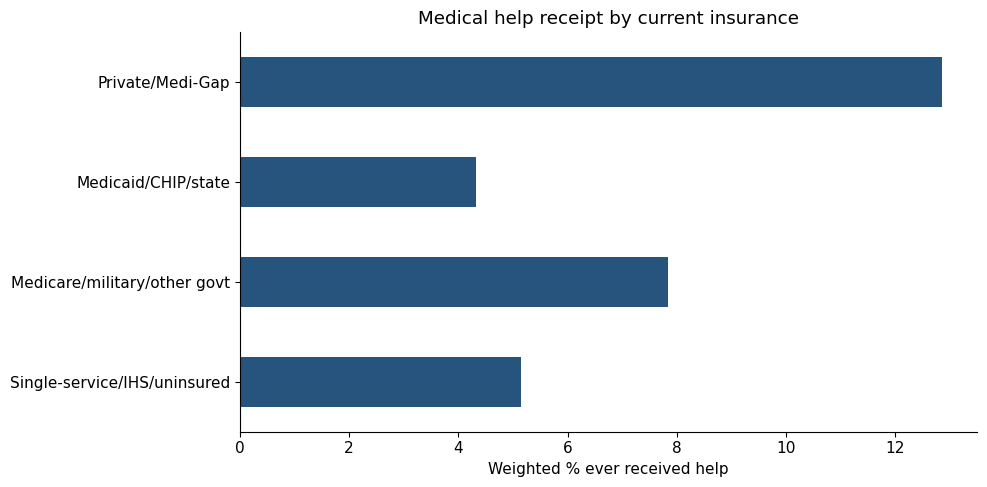

In [29]:
ax = rates.plot.barh(x="Insurance", y="Rate %", legend=False, color="#26547C", figsize=(10, 5))
ax.invert_yaxis()
ax.set(xlabel="Weighted % ever received help", ylabel="", title="Medical help receipt by current insurance")
plt.tight_layout()
plt.savefig(FIGURES / "help_received_by_insurance.png", dpi=300, bbox_inches="tight")
plt.show()

**Takeaway:** Weighted help receipt is approximately 12.9% for private coverage and 4.3% for Medicaid/CHIP/state coverage. This is an unadjusted comparison.

## 6. Help Receipt by Age, Income, and Education

,Group,N,Rate %
0,15–24,987,1.524
1,25–34,1814,8.048
2,35–44,1711,15.488
3,45–50,683,14.974


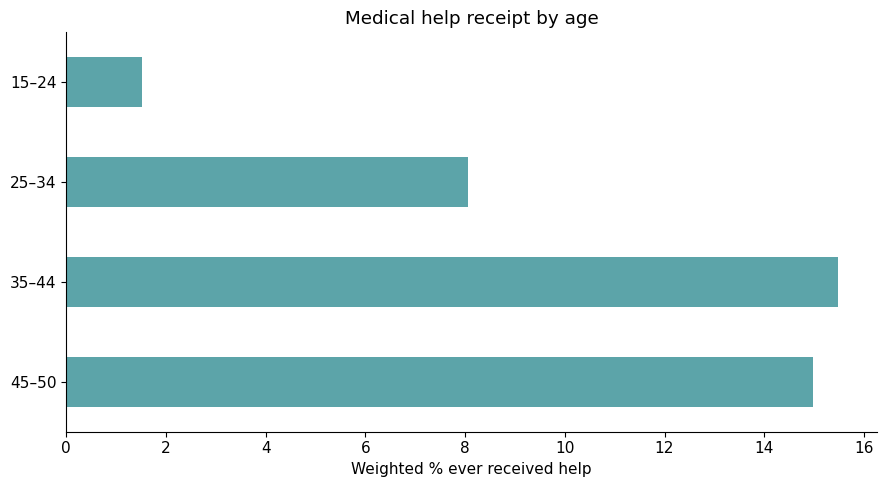

,Group,N,Rate %
0,≤100%,979,4.494
1,101–200%,934,6.863
2,201–400%,1362,9.822
3,>400%,1920,13.862


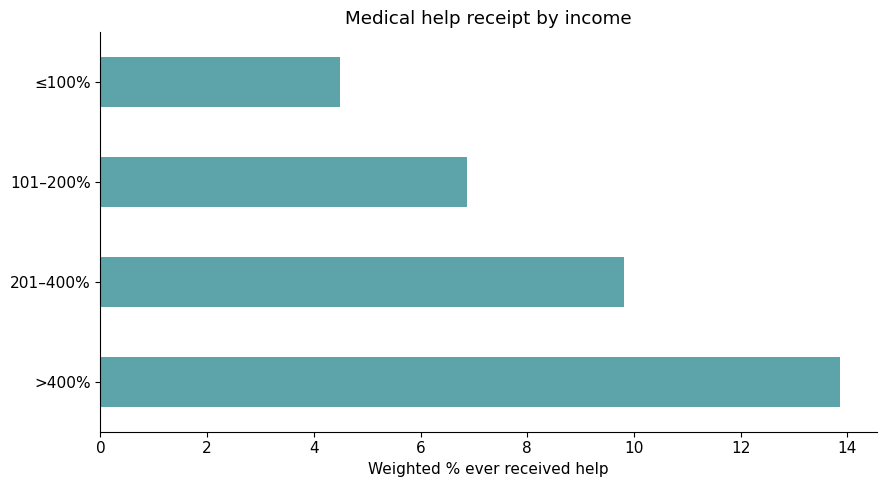

,Group,N,Rate %
0,Less than high school,462,4.301
1,High school/GED,937,4.775
2,Some college/associate,1575,8.438
3,Bachelor's or higher,2221,15.079


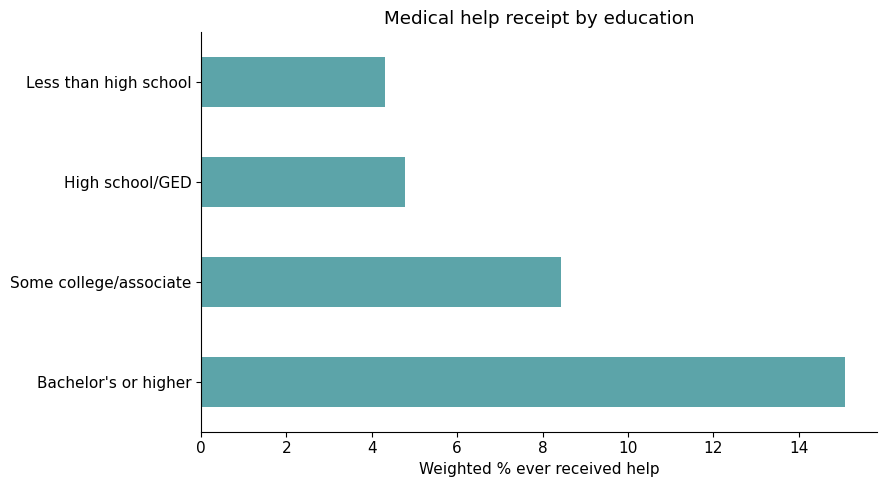

In [30]:
analysis["age_group"] = pd.cut(analysis["age"], bins=[14, 24, 34, 44, 50], labels=["15–24", "25–34", "35–44", "45–50"])
analysis["income_group"] = pd.cut(analysis["POVERTY"], bins=[0, 100, 200, 400, 700], labels=["≤100%", "101–200%", "201–400%", ">400%"])

# Create a table and chart for each variable
for variable, title in [("age_group", "Age"), ("income_group", "Income"), ("education", "Education")]:
    rows = []
    for label, group in analysis.groupby(variable, observed=True):
        rows.append({"Group": str(label), "N": len(group),
                     "Rate %": np.average(group["help_received"], weights=group["weight"])*100})
    table = pd.DataFrame(rows)
    display(table)
    table.to_csv(TABLES / f"help_by_{variable}.csv", index=False)
    ax = table.plot.barh(x="Group", y="Rate %", legend=False, color="#5CA4A9")
    ax.invert_yaxis()
    ax.set(xlabel="Weighted % ever received help", ylabel="", title=f"Medical help receipt by {title.lower()}")
    plt.tight_layout()
    plt.savefig(FIGURES / f"help_by_{variable}.png", dpi=300, bbox_inches="tight")
    plt.show()

**Takeaway:** Compare these rates to understand how help receipt varies with age, income, and education before adjustment.

## 7. Insurance Group Comparisons

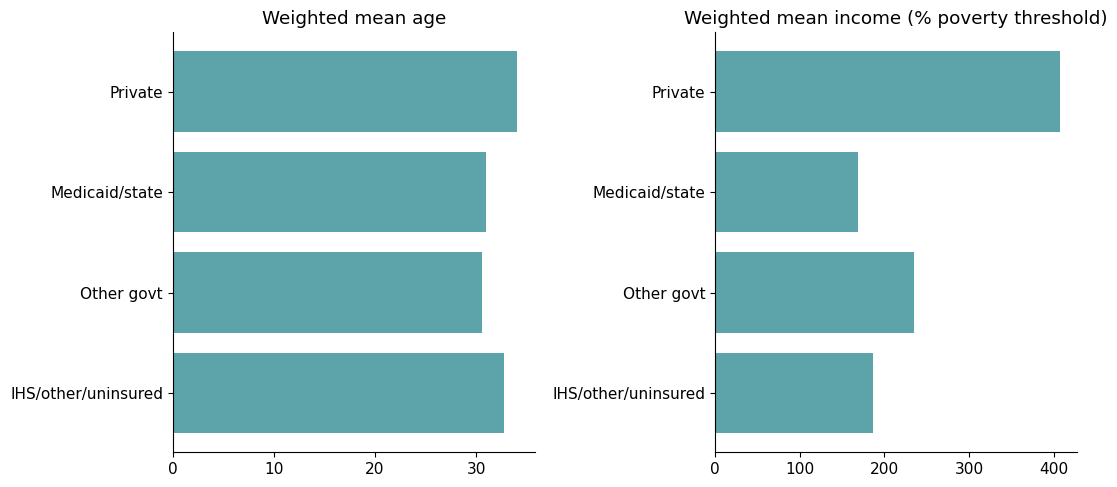

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
short_labels = ["Private", "Medicaid/state", "Other govt", "IHS/other/uninsured"]
for ax, col, title in zip(axes, ["Mean age", "Mean poverty %"], ["Weighted mean age", "Weighted mean income (% poverty threshold)"]):
    ax.barh(short_labels, rates[col], color="#5CA4A9")
    ax.invert_yaxis()
    ax.set_title(title)
fig.tight_layout()
fig.savefig(FIGURES / "confounder_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

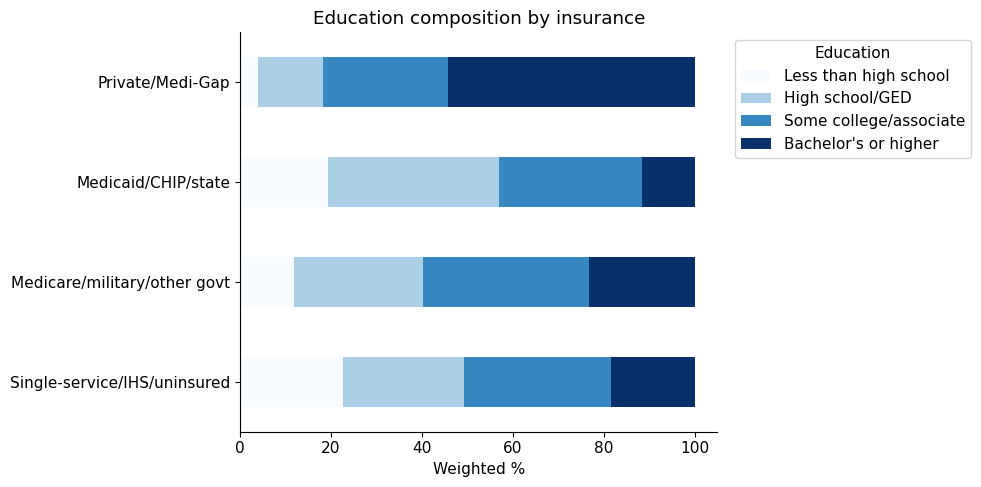

Age group,15–24,25–34,35–44,45–50
Insurance,,,,
Private/Medi-Gap,0.836,11.146,18.430,18.833
Medicaid/CHIP/state,2.982,2.845,6.285,8.467
Medicare/military/other govt,1.462,5.401,20.009,10.181
Single-service/IHS/uninsured,0.810,4.702,10.667,0.650


Age group,15–24,25–34,35–44,45–50
Insurance,,,,
Private/Medi-Gap,480,1063,1167,472
Medicaid/CHIP/state,283,409,300,103
Medicare/military/other govt,115,113,82,33
Single-service/IHS/uninsured,109,229,162,75


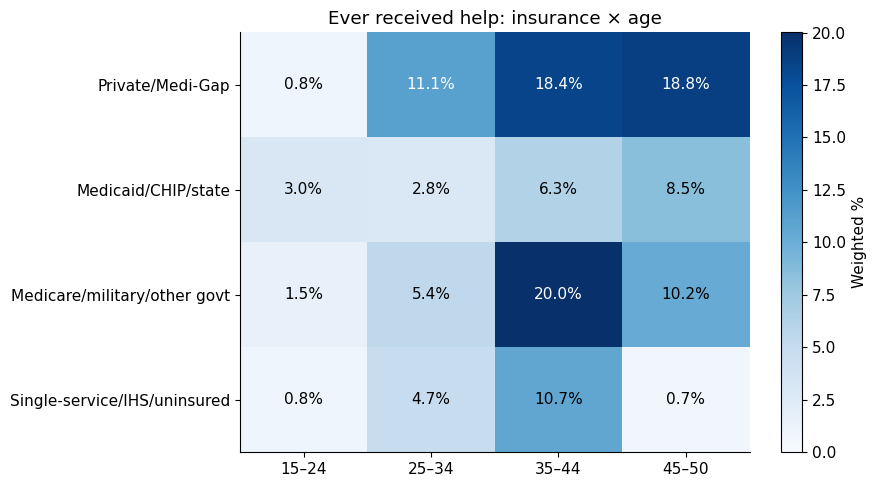

In [32]:
# Education composition by insurance
ax = education_share.plot.barh(stacked=True, figsize=(10, 5), colormap="Blues")
ax.set(xlabel="Weighted %", ylabel="", title="Education composition by insurance")
ax.invert_yaxis()
ax.legend(title="Education", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIGURES / "education_composition.png", dpi=200, bbox_inches="tight")
plt.show()

# Weighted help-receipt rates within insurance × age groups
cross = []
for (insurance, age_group), g in analysis.groupby(["insurance", "age_group"], observed=True):
    cross.append({"Insurance": insurance, "Age group": age_group, "N": len(g), "Rate %": np.average(g.help_received, weights=g.weight)*100})
cross = pd.DataFrame(cross)
rate_grid = cross.pivot(index="Insurance", columns="Age group", values="Rate %").reindex(insurance_labels)
count_grid = cross.pivot(index="Insurance", columns="Age group", values="N").reindex(insurance_labels)
display(rate_grid)
display(count_grid)
cross.to_csv(TABLES / "insurance_age_cross_tab.csv", index=False)
fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(rate_grid.to_numpy(), cmap="Blues", aspect="auto", vmin=0)
ax.set_xticks(range(len(rate_grid.columns)), rate_grid.columns)
ax.set_yticks(range(len(rate_grid)), rate_grid.index)
for i in range(len(rate_grid)):
    for j in range(len(rate_grid.columns)):
        value = rate_grid.iloc[i, j]
        ax.text(j, i, f"{value:.1f}%", ha="center", va="center", color="white" if value > np.nanmax(rate_grid.to_numpy())*.55 else "black")
ax.set_title("Ever received help: insurance × age")
fig.colorbar(im, ax=ax, label="Weighted %")
fig.tight_layout()
fig.savefig(FIGURES / "insurance_age_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()

**Takeaway:** Insurance groups differ in their characteristics. Check counts before interpreting rates from small subgroups.

## 8. Survey-Weighted Logistic Regression

Outcome: ever received help (1/0). Controls: age, income, and education. Reference groups: private insurance and less than high school. `svy` handles weights, strata, and clusters.

In [33]:
# Preserve all respondents for survey variance estimation
survey_data = data.copy()
survey_data["included"] = data.index.isin(analysis.index)

# Use ordinary strings for categorical predictors
survey_data["insurance"] = survey_data["insurance"].astype("string")
survey_data["education"] = survey_data["education"].astype("string")

survey = svy.Sample(
    data=pl.from_pandas(survey_data),
    design=svy.Design(stratum="VEST", psu="VECL", wgt="weight")
)

# Insurance-only model
unadjusted_model = survey.glm.fit(
    y="help_received",
    x=[svy.Cat("insurance", ref="Private/Medi-Gap")],
    family="binomial", link="logit",
    where=svy.col("included") == True
)

# Model with controls
model = survey.glm.fit(
    y="help_received",
    x=[svy.Cat("insurance", ref="Private/Medi-Gap"),
       "poverty100",
       svy.Cat("education", ref="Less than high school"),
       "age"],
    family="binomial", link="logit",
    where=svy.col("included") == True
)

## 9. Model Results

In [34]:
# Convert log-odds coefficients into odds ratios
results = model.to_polars().to_pandas()
results["OR"] = np.exp(results["estimate"])
results["Lower OR"] = np.exp(results["conf_low"])
results["Upper OR"] = np.exp(results["conf_high"])
display(results[["term", "OR", "Lower OR", "Upper OR", "p_value"]])
results.to_csv(TABLES / "adjusted_logit.csv", index=False)

# Compare insurance coefficients before and after controls
unadjusted_results = unadjusted_model.to_polars().to_pandas()
unadjusted_results["Unadjusted OR"] = np.exp(unadjusted_results["estimate"])
comparison = results[results["term"].str.startswith("insurance_")][
    ["term", "OR", "Lower OR", "Upper OR", "p_value"]
].merge(unadjusted_results[["term", "Unadjusted OR"]], on="term")
display(comparison)
comparison.to_csv(TABLES / "insurance_model_comparison.csv", index=False)

,term,OR,Lower OR,Upper OR,p_value
0,_intercept_,0.008,0.004,0.017,3.362e-17
1,insurance_Medicaid/CHIP/state,0.538,0.356,0.813,3.965e-03
2,insurance_Medicare/military/other govt,0.861,0.463,1.604,6.318e-01
3,insurance_Single-service/IHS/uninsured,0.560,0.324,0.968,3.831e-02
4,poverty100,1.043,0.972,1.120,2.357e-01
5,education_Bachelor's or higher,2.166,1.152,4.072,1.747e-02
6,education_High school/GED,1.093,0.572,2.090,7.844e-01
7,education_Some college/associate,1.531,0.797,2.943,1.966e-01
8,age,1.062,1.048,1.077,1.003e-11


,term,OR,Lower OR,Upper OR,p_value,Unadjusted OR
0,insurance_Medicaid/CHIP/state,0.538,0.356,0.813,0.004,0.306
1,insurance_Medicare/military/other govt,0.861,0.463,1.604,0.632,0.577
2,insurance_Single-service/IHS/uninsured,0.560,0.324,0.968,0.038,0.368


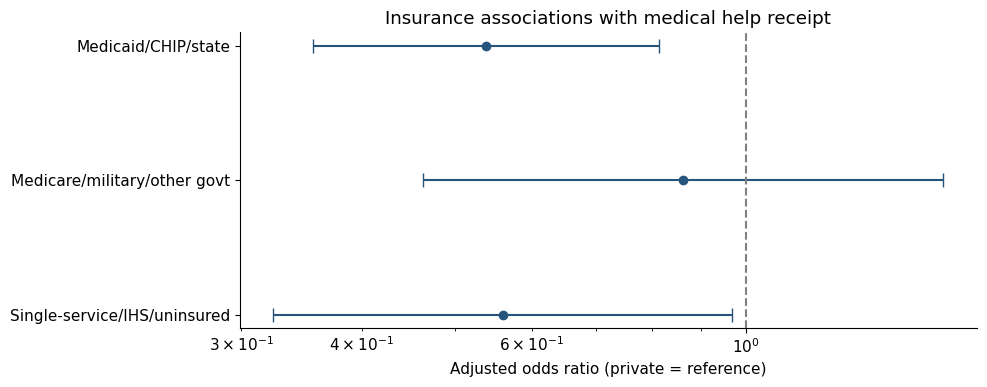

In [35]:
# Plot the adjusted insurance odds ratios
insurance_results = results[results["term"].str.startswith("insurance_")].copy()
insurance_results["Label"] = insurance_results["term"].str.replace("insurance_", "", regex=False)
fig, ax = plt.subplots(figsize=(10, 4))
ax.errorbar(
    insurance_results["OR"], insurance_results["Label"],
    xerr=[insurance_results["OR"]-insurance_results["Lower OR"],
          insurance_results["Upper OR"]-insurance_results["OR"]],
    fmt="o", capsize=5, color="#26547C"
)
ax.axvline(1, color="gray", linestyle="--")
ax.set_xscale("log")
ax.invert_yaxis()
ax.set(xlabel="Adjusted odds ratio (private = reference)", title="Insurance associations with medical help receipt")
plt.tight_layout()
plt.savefig(FIGURES / "adjusted_insurance_odds_ratios.png", dpi=300, bbox_inches="tight")
plt.show()

**Takeaway:** An odds ratio below 1 indicates lower odds relative to the reference group. A 95% confidence interval crossing 1 indicates uncertainty about the direction.